In [1]:
# importaçoes
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

# modelagem 
from catboost import CatBoostClassifier
from xgboost import XGBClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, recall_score, log_loss, average_precision_score, 
                            roc_auc_score, auc, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')

In [2]:
# carregando dados 
train_path = os.path.join('..', 'data', 'raw', 'application_train.csv')
test_path = os.path.join('..', 'data', 'raw', 'application_test.csv')
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f'dados de treino carregados com sucesso. dimensoes: linhas: {df_train.shape[0]} | colunas: {df_train.shape[1]}')
print()
print(f'dados de teste carregados com sucesso. dimensoes: linhas: {df_test.shape[0]} | colunas: {df_test.shape[1]}')

dados de treino carregados com sucesso. dimensoes: linhas: 307511 | colunas: 122

dados de teste carregados com sucesso. dimensoes: linhas: 48744 | colunas: 121


In [3]:
#funcoes auxiliares 
# funçao para plot de distribuiçoes 
def plot_cat_num_features(data: pd.DataFrame, batch_size=10):
    cat_col = data.select_dtypes(exclude="number").columns
    num_col = data.select_dtypes(include="number")
    if len(cat_col) > 1:
        fig1, axes1 = plt.subplots(ncols=1, nrows=len(cat_col), figsize=(16, 3.5 * len(cat_col)))
        for ax, cat in zip(axes1, cat_col):
            sns.countplot(data=data, x=cat, palette="viridis", ax=ax)
            ax.set_title(f"{cat}")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        plt.close(fig1)  
    if len(cat_col) == 1:
        fig = plt.figure(figsize=(12, 8))
        plt.title(f"{cat_col[0]}")
        ax = sns.countplot(data=data, x=cat_col[0], palette="viridis")
        plt.xticks(rotation=90)
        for container in ax.containers:
            ax.bar_label(container, fontsize=10)
        plt.tight_layout()
        plt.show()
        plt.close(fig)  
    if len(num_col.columns) > 1:
        cols = num_col.columns.tolist()
        for start in range(0, len(cols), batch_size):
            batch = cols[start : start + batch_size]
            fig, axes = plt.subplots(ncols=2, nrows=len(batch), figsize=(16, 3.5 * len(batch)))
            if len(batch) == 1:
                axes = axes.reshape(1, 2)
            for i, num in enumerate(batch):
                sns.histplot(ax=axes[i, 0], data=data, x=num, kde=True)
                sns.boxplot(ax=axes[i, 1], data=data, x=num)
                axes[i, 0].set_title(f"Histograma - {num}")
                axes[i, 1].set_title(f"BoxPlot - {num}")
            fig.tight_layout()
            plt.show()
            plt.close(fig)  
    if len(num_col.columns) == 1:
        fig = plt.figure(figsize=(12, 8))
        plt.title(f"{num_col.columns[0]}")
        sns.boxplot(data=data, x=num_col.columns[0])
        plt.tight_layout()
        plt.show()
        plt.close(fig)  
    return num_col.describe().T

# verifica a quantidade de nulos em funçao de um limiar e retorna quais sao as colunas em uma lista
def is_null(data:pd.DataFrame, limiar:float):
    df_null = data.isnull().mean().sort_values(ascending=False)
    print('======'*40)
    print(f'COLUNAS COM % DE NAN MAIOR QUE {limiar}')
    print('======'*40)
    print
    col_return = []
    k =0 
    for name, num in df_null.items() :
        if num >=limiar:
            print(f'{name}: {num}')
            k+=1
            col_return.append(name)
    print(f'quantidade de colunas nulas em funçao do limiar: {k}')
    return col_return

#plot heatmap 
def plot_heatmap(data: pd.DataFrame, title:str):
    try:
        plt.figure(figsize=(12,8))
        plt.title(f'{title}')
        sns.heatmap(data, cmap='crest', robust=True)
        plt.tight_layout()
        plt.show()
    except ValueError as e:
        return {f'apenas colunas numericas {e}'}
    
# kde plot
def kde_plot(data:pd.DataFrame, hue:str):
    num_cols = data.select_dtypes(include='number')
    fig, axes = plt.subplots(nrows=len(num_cols.columns)-1, ncols=1, figsize=(16, 3.5 * len(num_cols.columns)))
    for ax, num in zip(axes, num_cols.columns):
        if num != hue:
            sns.kdeplot(data=df_train, x=num, hue=hue, ax=ax)
    fig.tight_layout()
    fig.show()
    
# funcao metricas 
def metrics(y_real, y_prob, limiar:float):
    y_pred = np.where(y_prob >=limiar, 1,0)
    fpr, tpr, _ = roc_curve(y_real, y_prob)
    ks = max(tpr-fpr)
    recall = recall_score(y_real, y_pred)
    logLoss = log_loss(y_real, y_prob)
    avg_precision = average_precision_score(y_real, y_prob)
    roc_auc = roc_auc_score(y_real, y_prob)
    f1_score_ = f1_score(y_real, y_pred, zero_division=0)
    output = {"KS":ks,
            "Recall Score": recall, 
            "LogLoss":logLoss, 
            #"AVG_Precision": avg_precision, 
            "Roc Auc": roc_auc, 
            "F1":f1_score_
            }
    return pd.DataFrame([output])

In [4]:
df_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_train = df_train.set_index('SK_ID_CURR')

In [6]:
# verificando % de nan no dataframe de treino
df_train.isnull().mean().sort_values(ascending=False)

COMMONAREA_AVG              0.698723
COMMONAREA_MEDI             0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
                              ...   
FLAG_DOCUMENT_16            0.000000
FLAG_DOCUMENT_15            0.000000
FLAG_DOCUMENT_14            0.000000
FLAG_DOCUMENT_20            0.000000
FLAG_DOCUMENT_21            0.000000
Length: 121, dtype: float64

In [7]:
drop_cols = is_null(df_train, 0.15)

COLUNAS COM % DE NAN MAIOR QUE 0.15
COMMONAREA_AVG: 0.6987229725115525
COMMONAREA_MEDI: 0.6987229725115525
COMMONAREA_MODE: 0.6987229725115525
NONLIVINGAPARTMENTS_AVG: 0.6943296337366793
NONLIVINGAPARTMENTS_MEDI: 0.6943296337366793
NONLIVINGAPARTMENTS_MODE: 0.6943296337366793
FONDKAPREMONT_MODE: 0.6838617155158677
LIVINGAPARTMENTS_MEDI: 0.6835495315614726
LIVINGAPARTMENTS_AVG: 0.6835495315614726
LIVINGAPARTMENTS_MODE: 0.6835495315614726
FLOORSMIN_MODE: 0.6784862980511266
FLOORSMIN_AVG: 0.6784862980511266
FLOORSMIN_MEDI: 0.6784862980511266
YEARS_BUILD_MODE: 0.6649778381911542
YEARS_BUILD_MEDI: 0.6649778381911542
YEARS_BUILD_AVG: 0.6649778381911542
OWN_CAR_AGE: 0.6599081008484249
LANDAREA_MEDI: 0.5937673774271489
LANDAREA_AVG: 0.5937673774271489
LANDAREA_MODE: 0.5937673774271489
BASEMENTAREA_MODE: 0.5851595552679416
BASEMENTAREA_AVG: 0.5851595552679416
BASEMENTAREA_MEDI: 0.5851595552679416
EXT_SOURCE_1: 0.5638107254699832
NONLIVINGAREA_AVG: 0.5517916432257708
NONLIVINGAREA_MODE: 0.551791

In [8]:
# dropando colunas 
df_train = df_train.drop(drop_cols, axis=1)

In [9]:
# dropando quantidades insignificantes de nulos 
df_train = df_train.dropna()

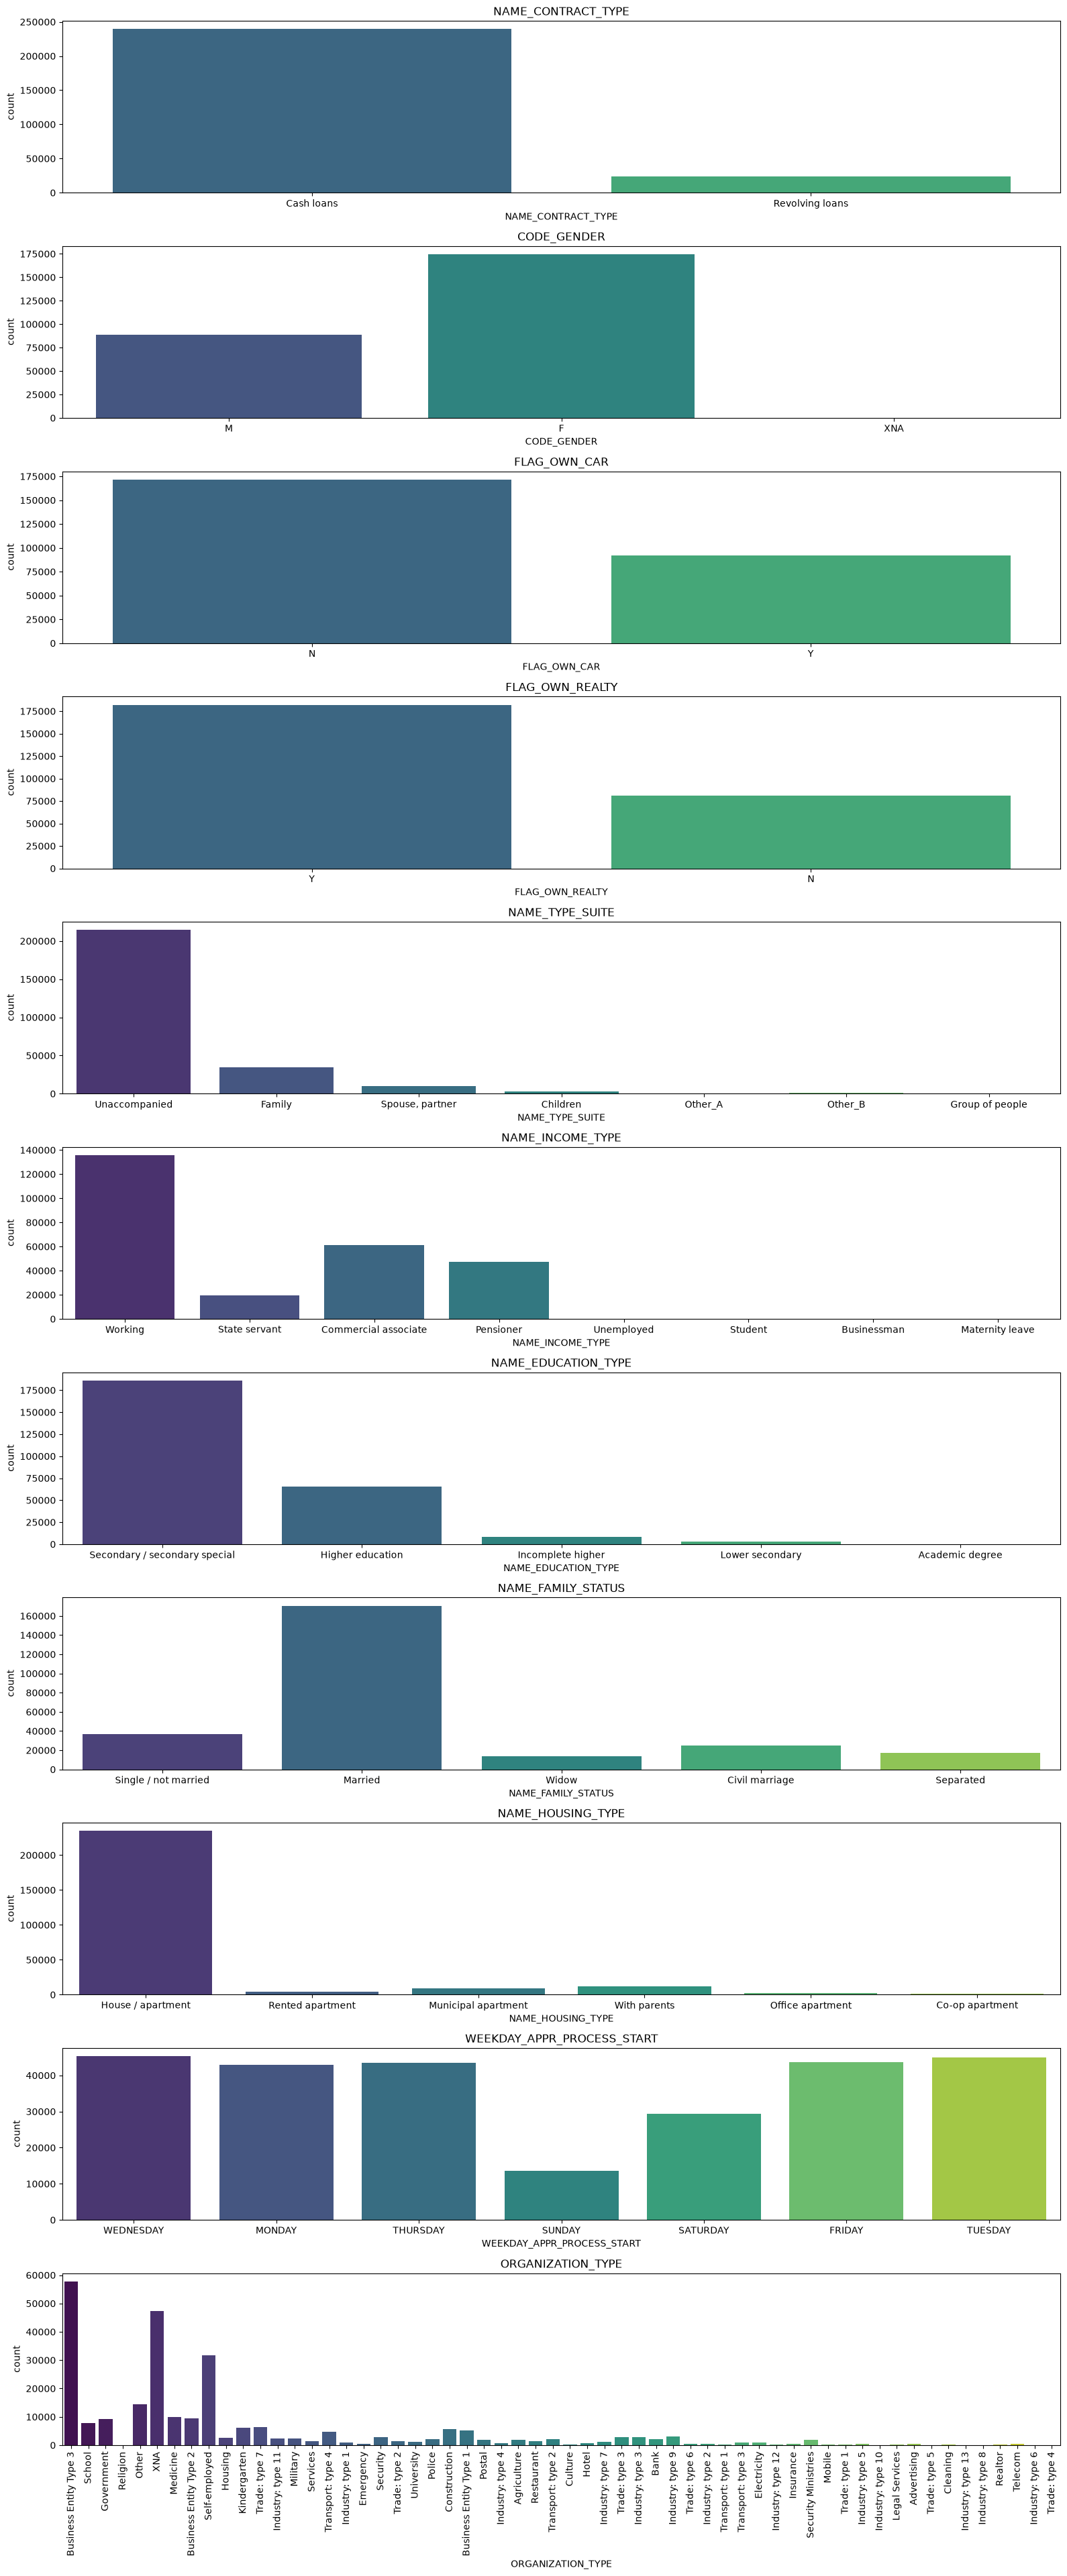

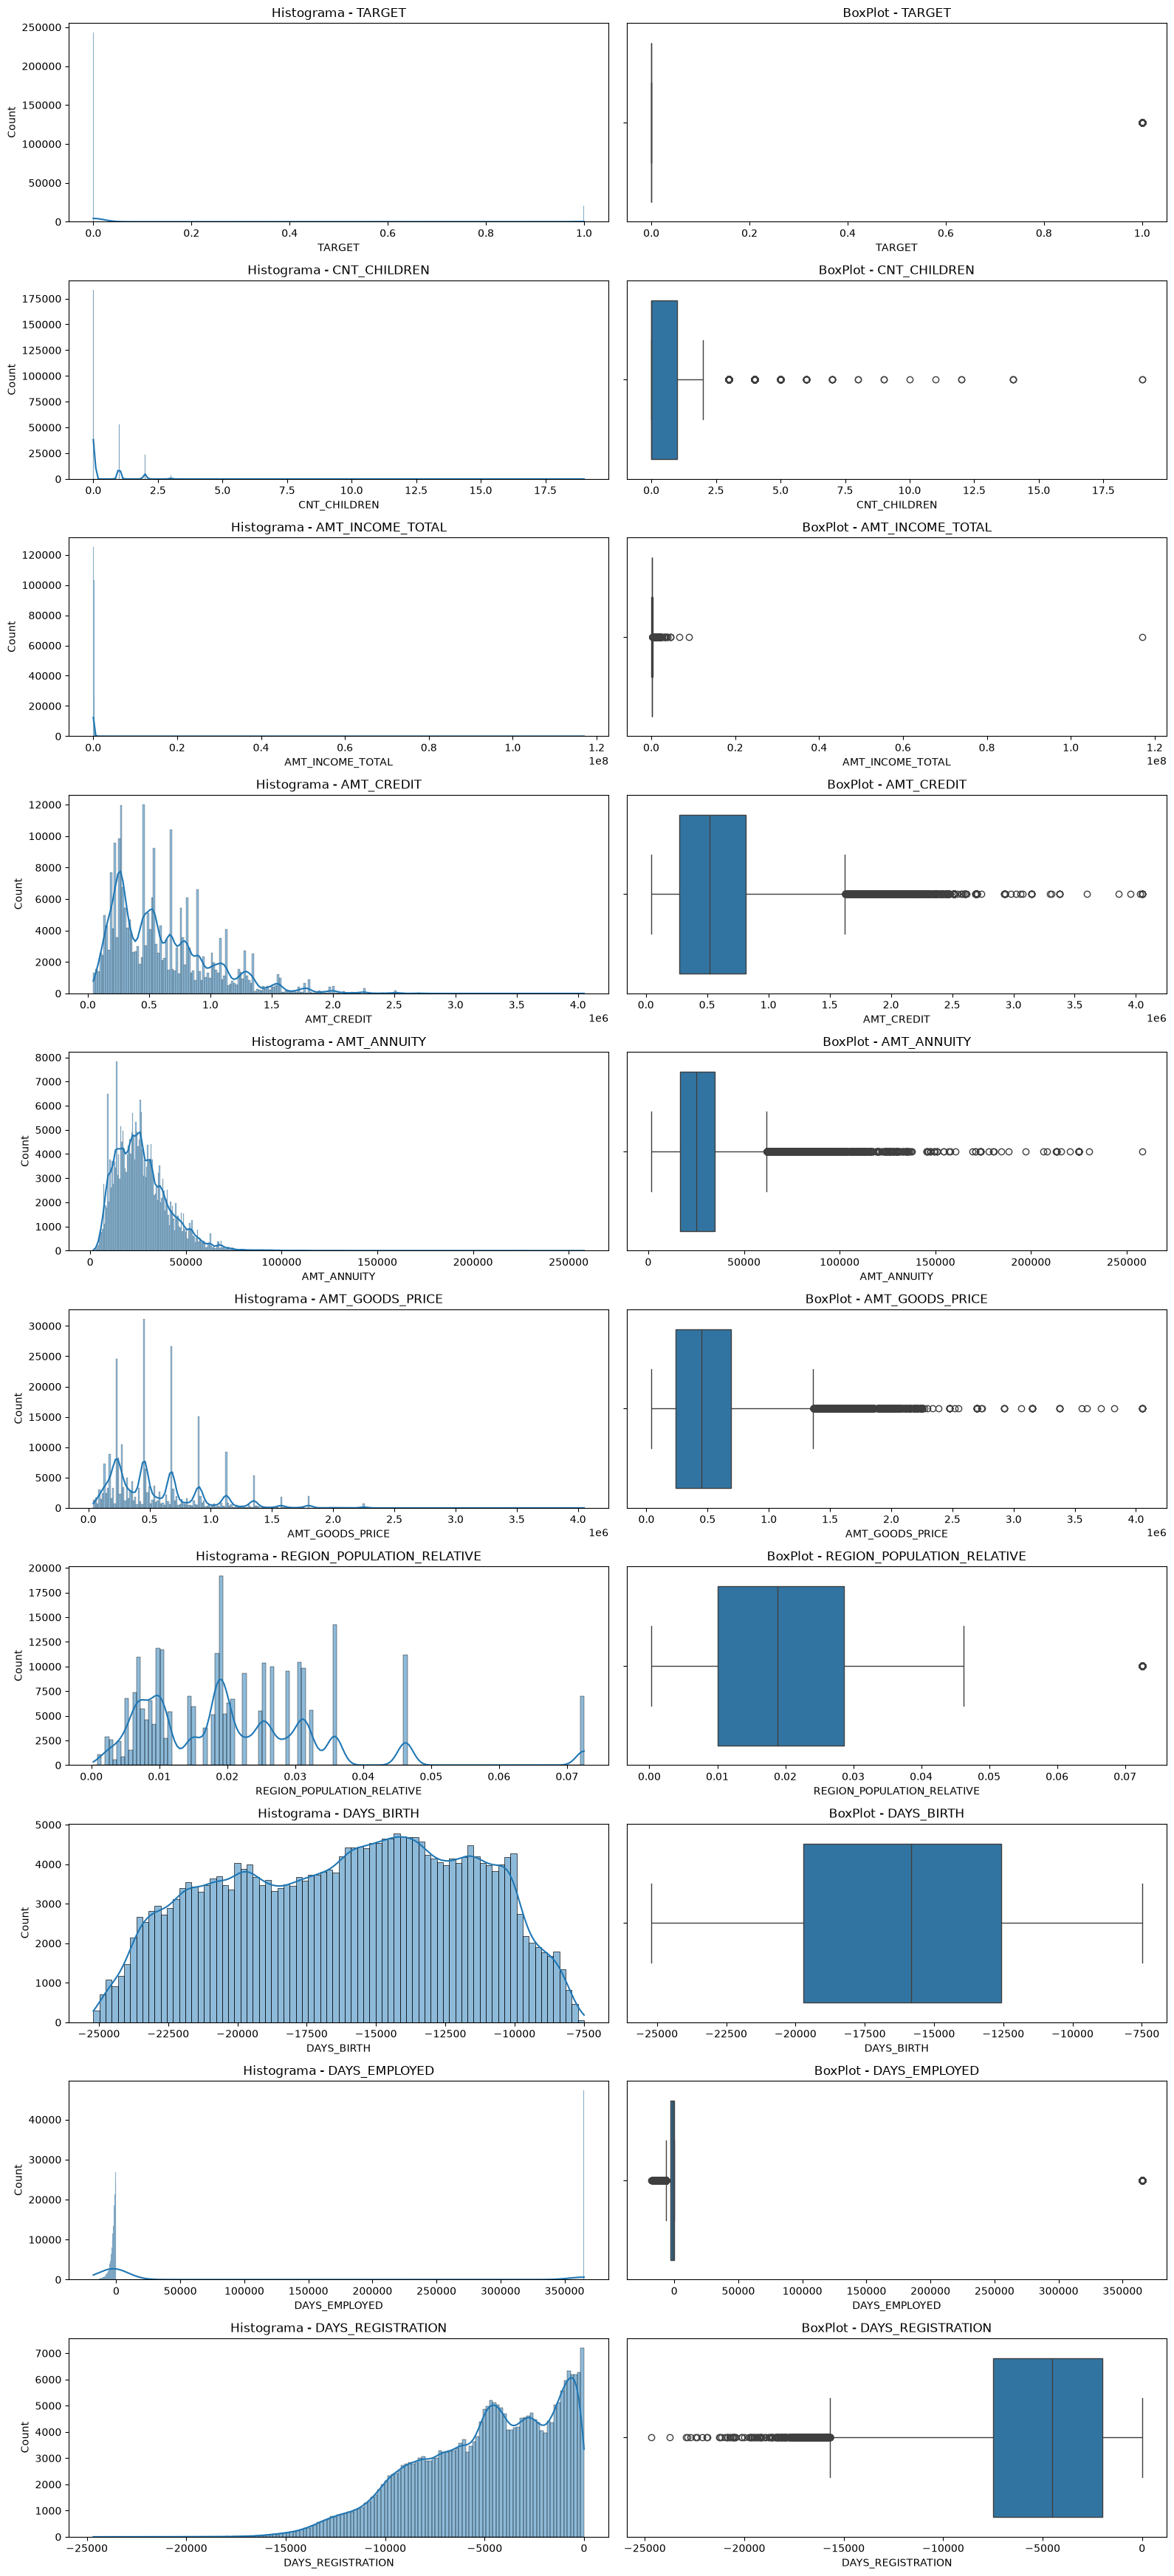

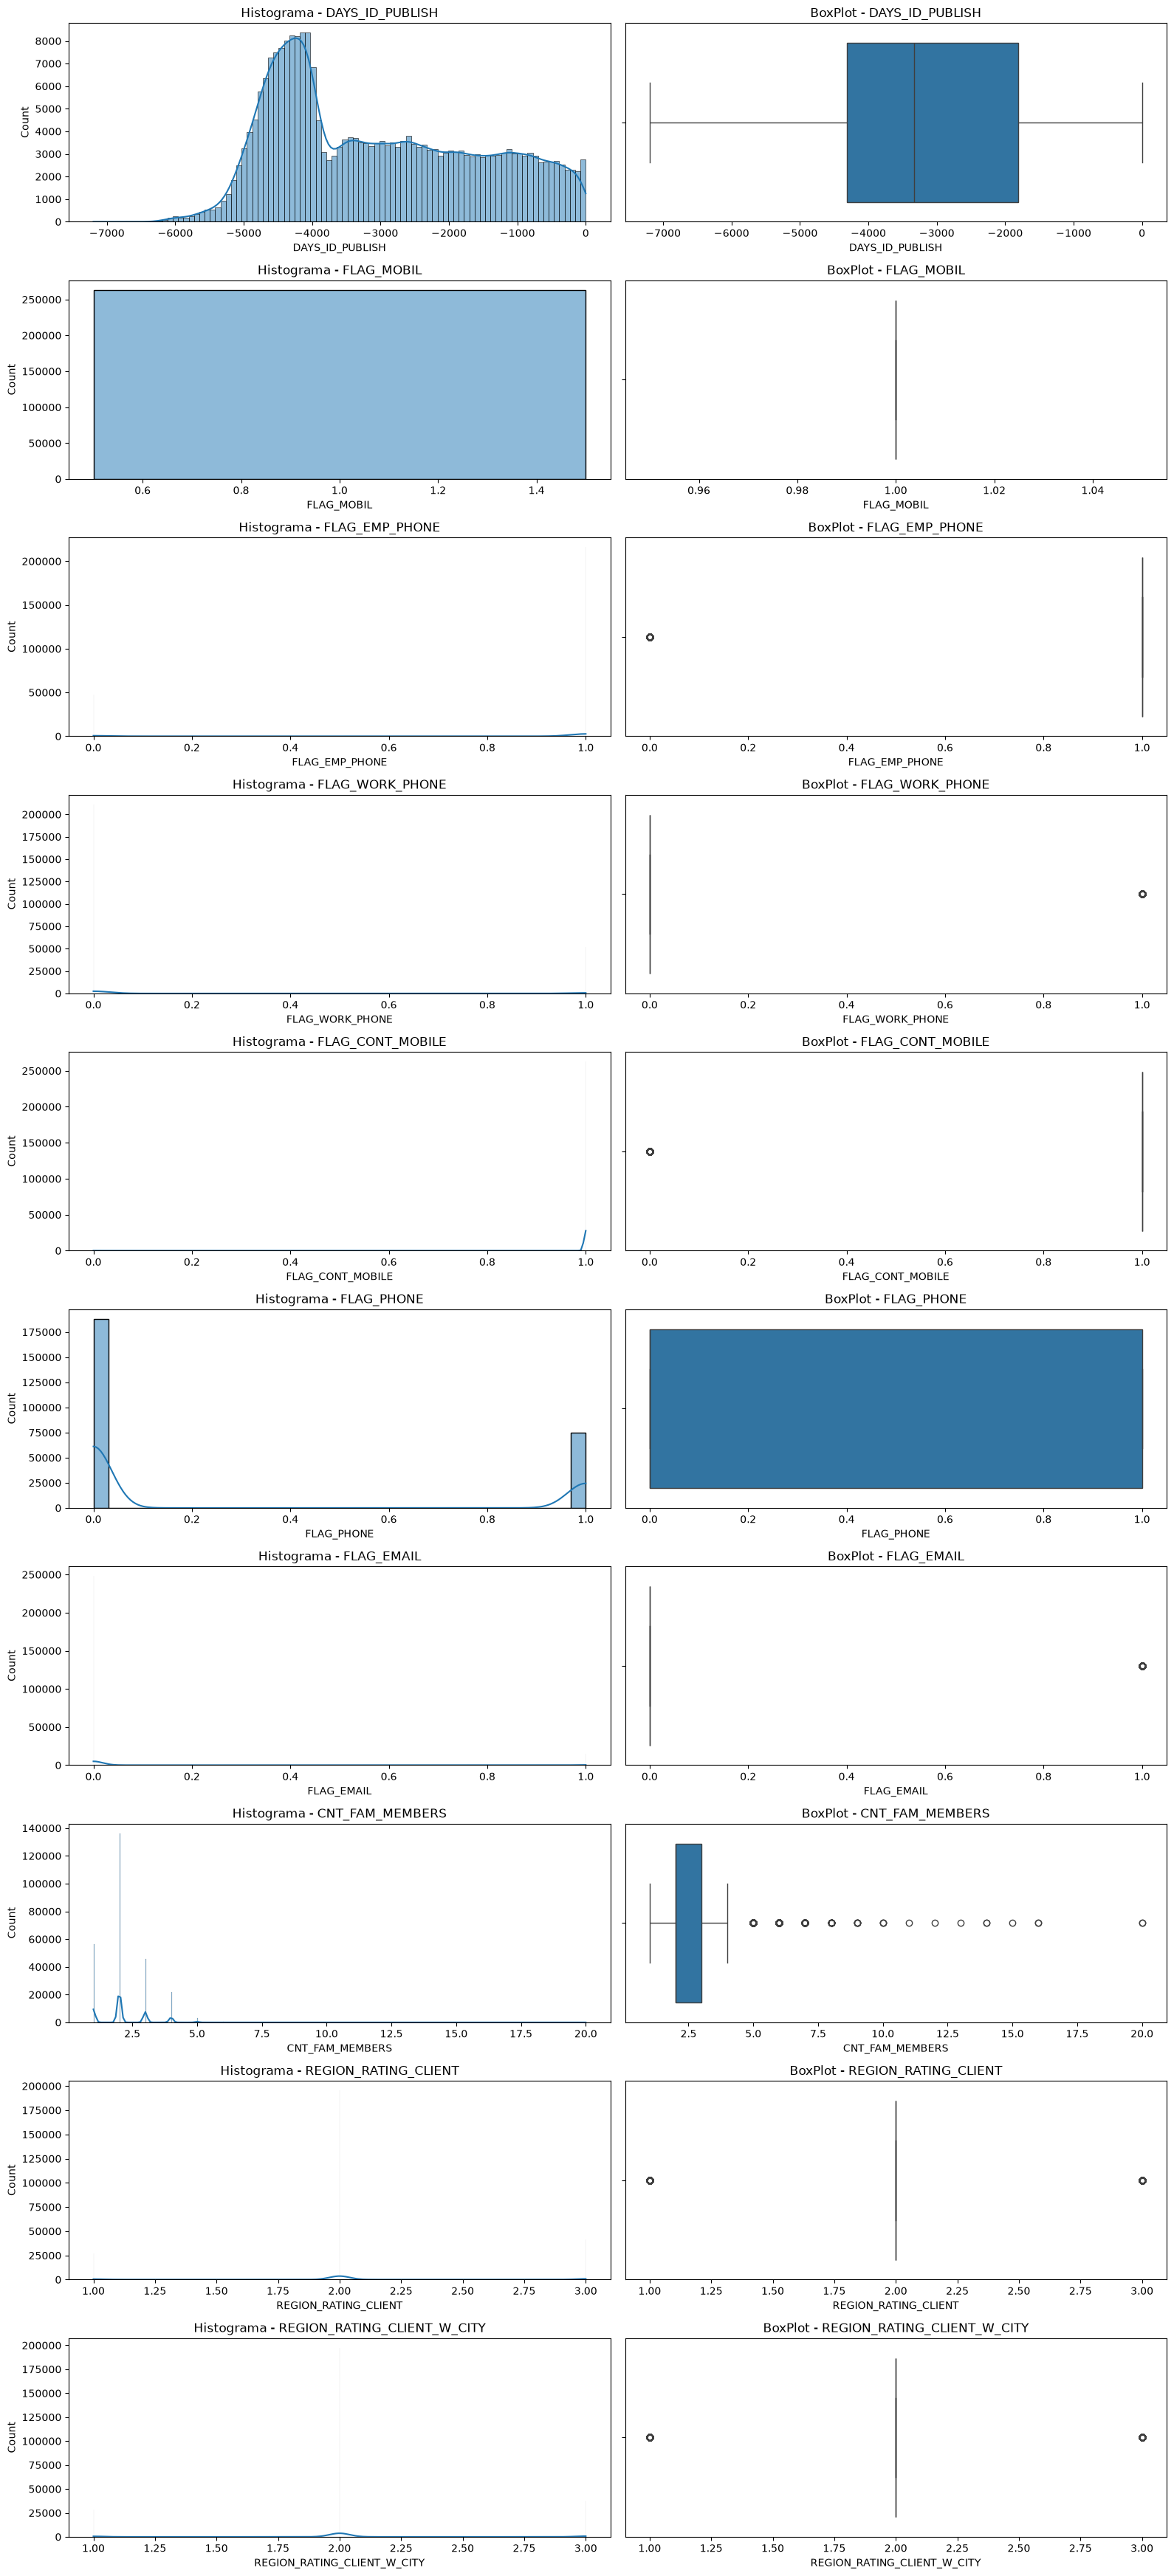

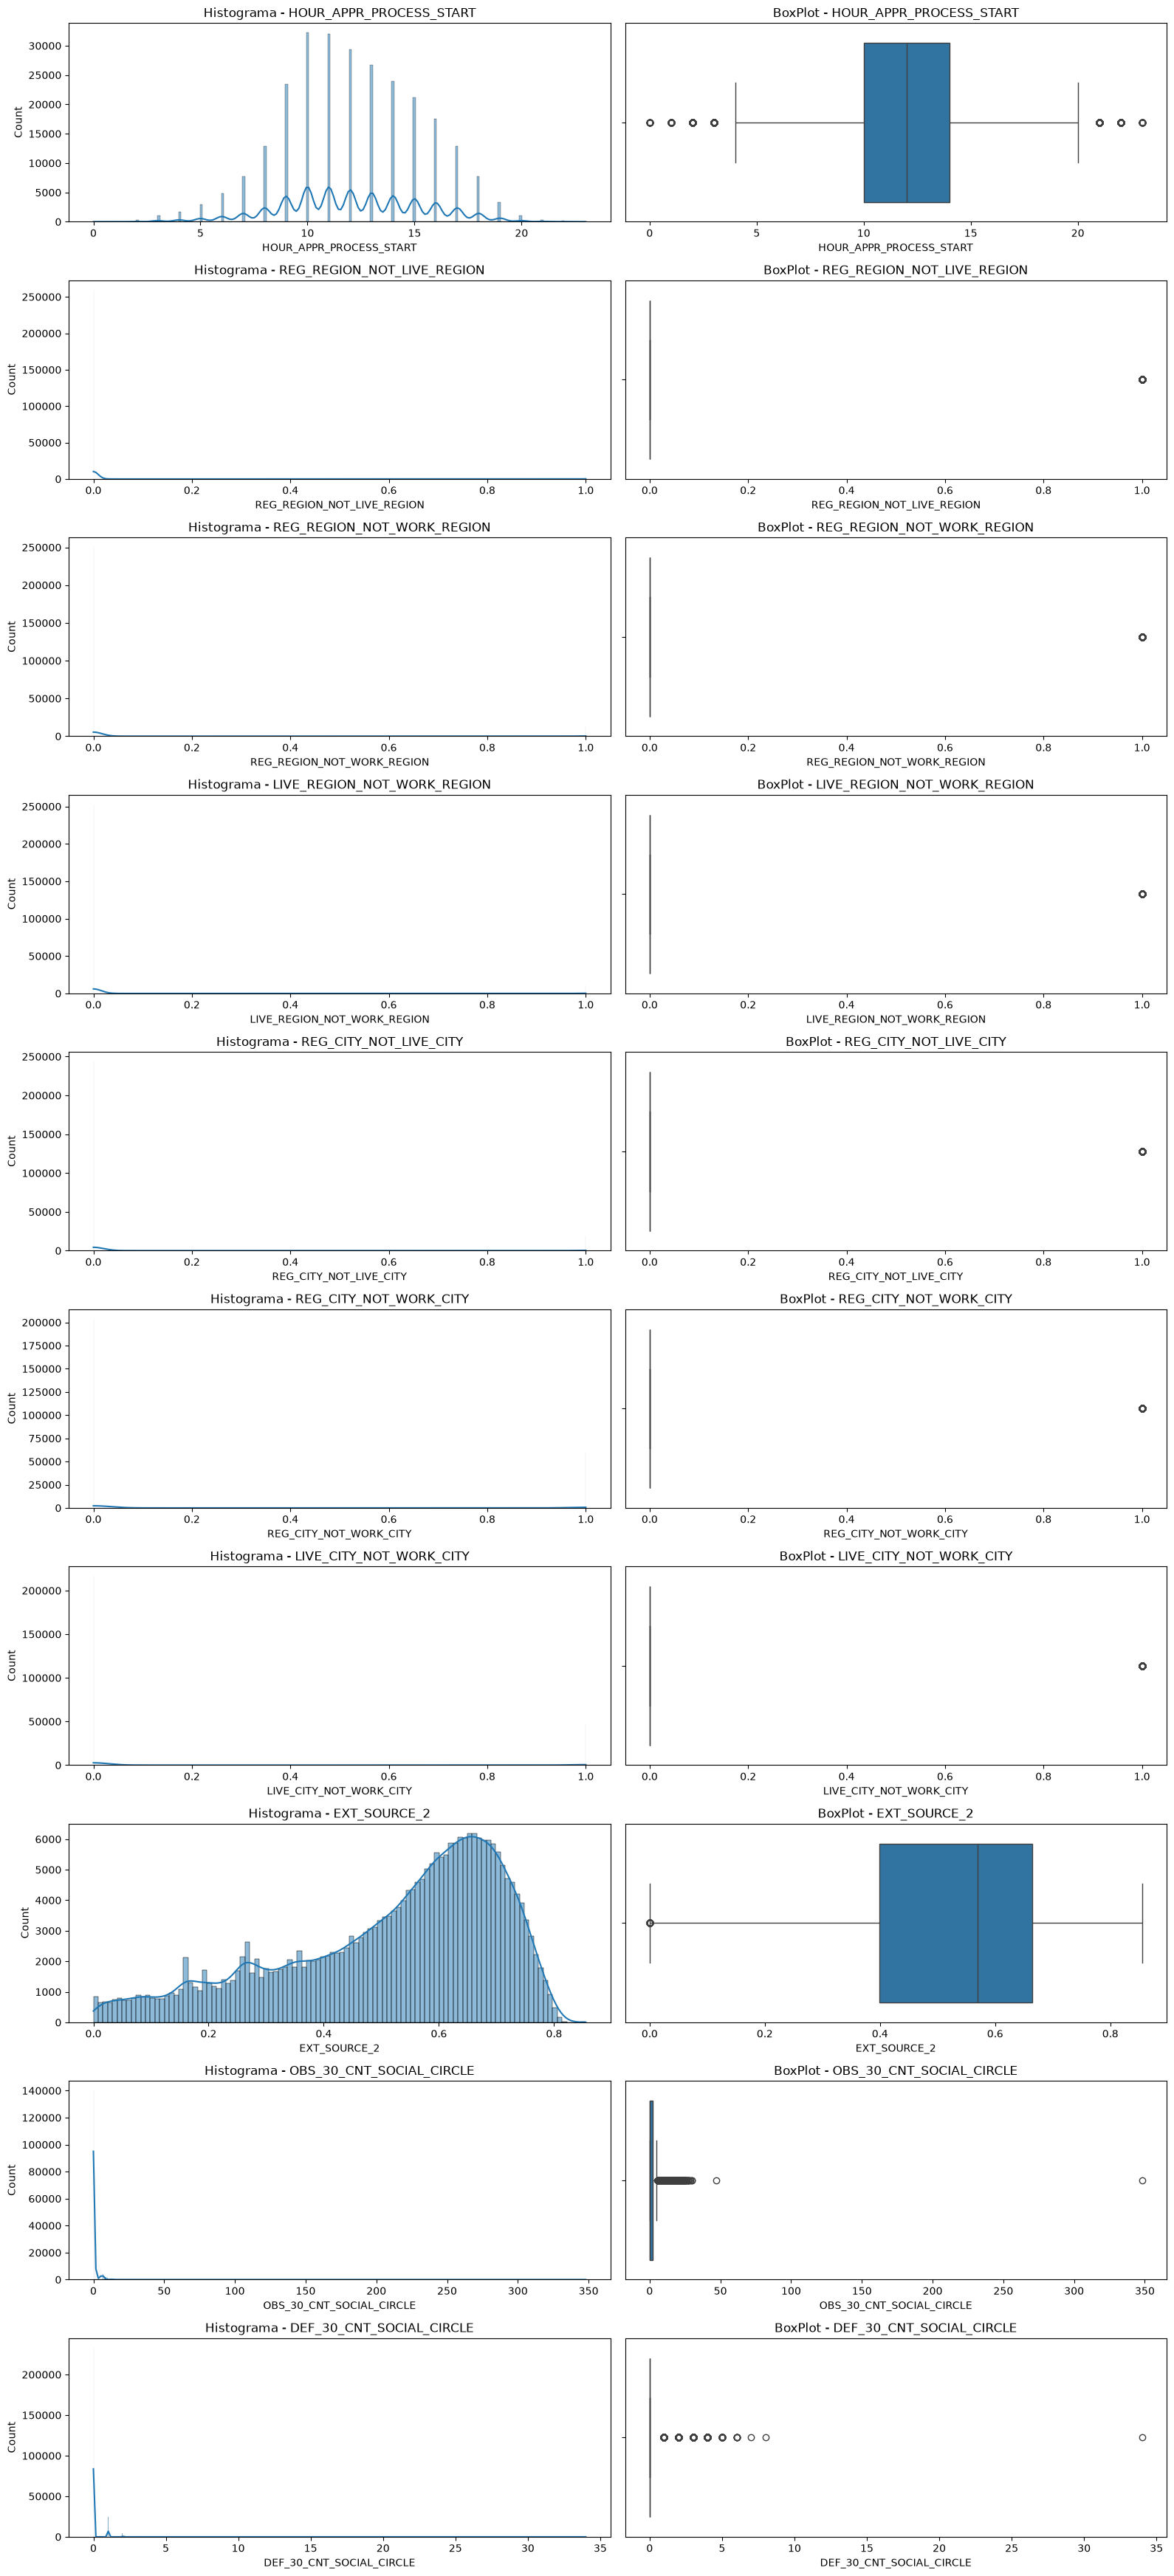

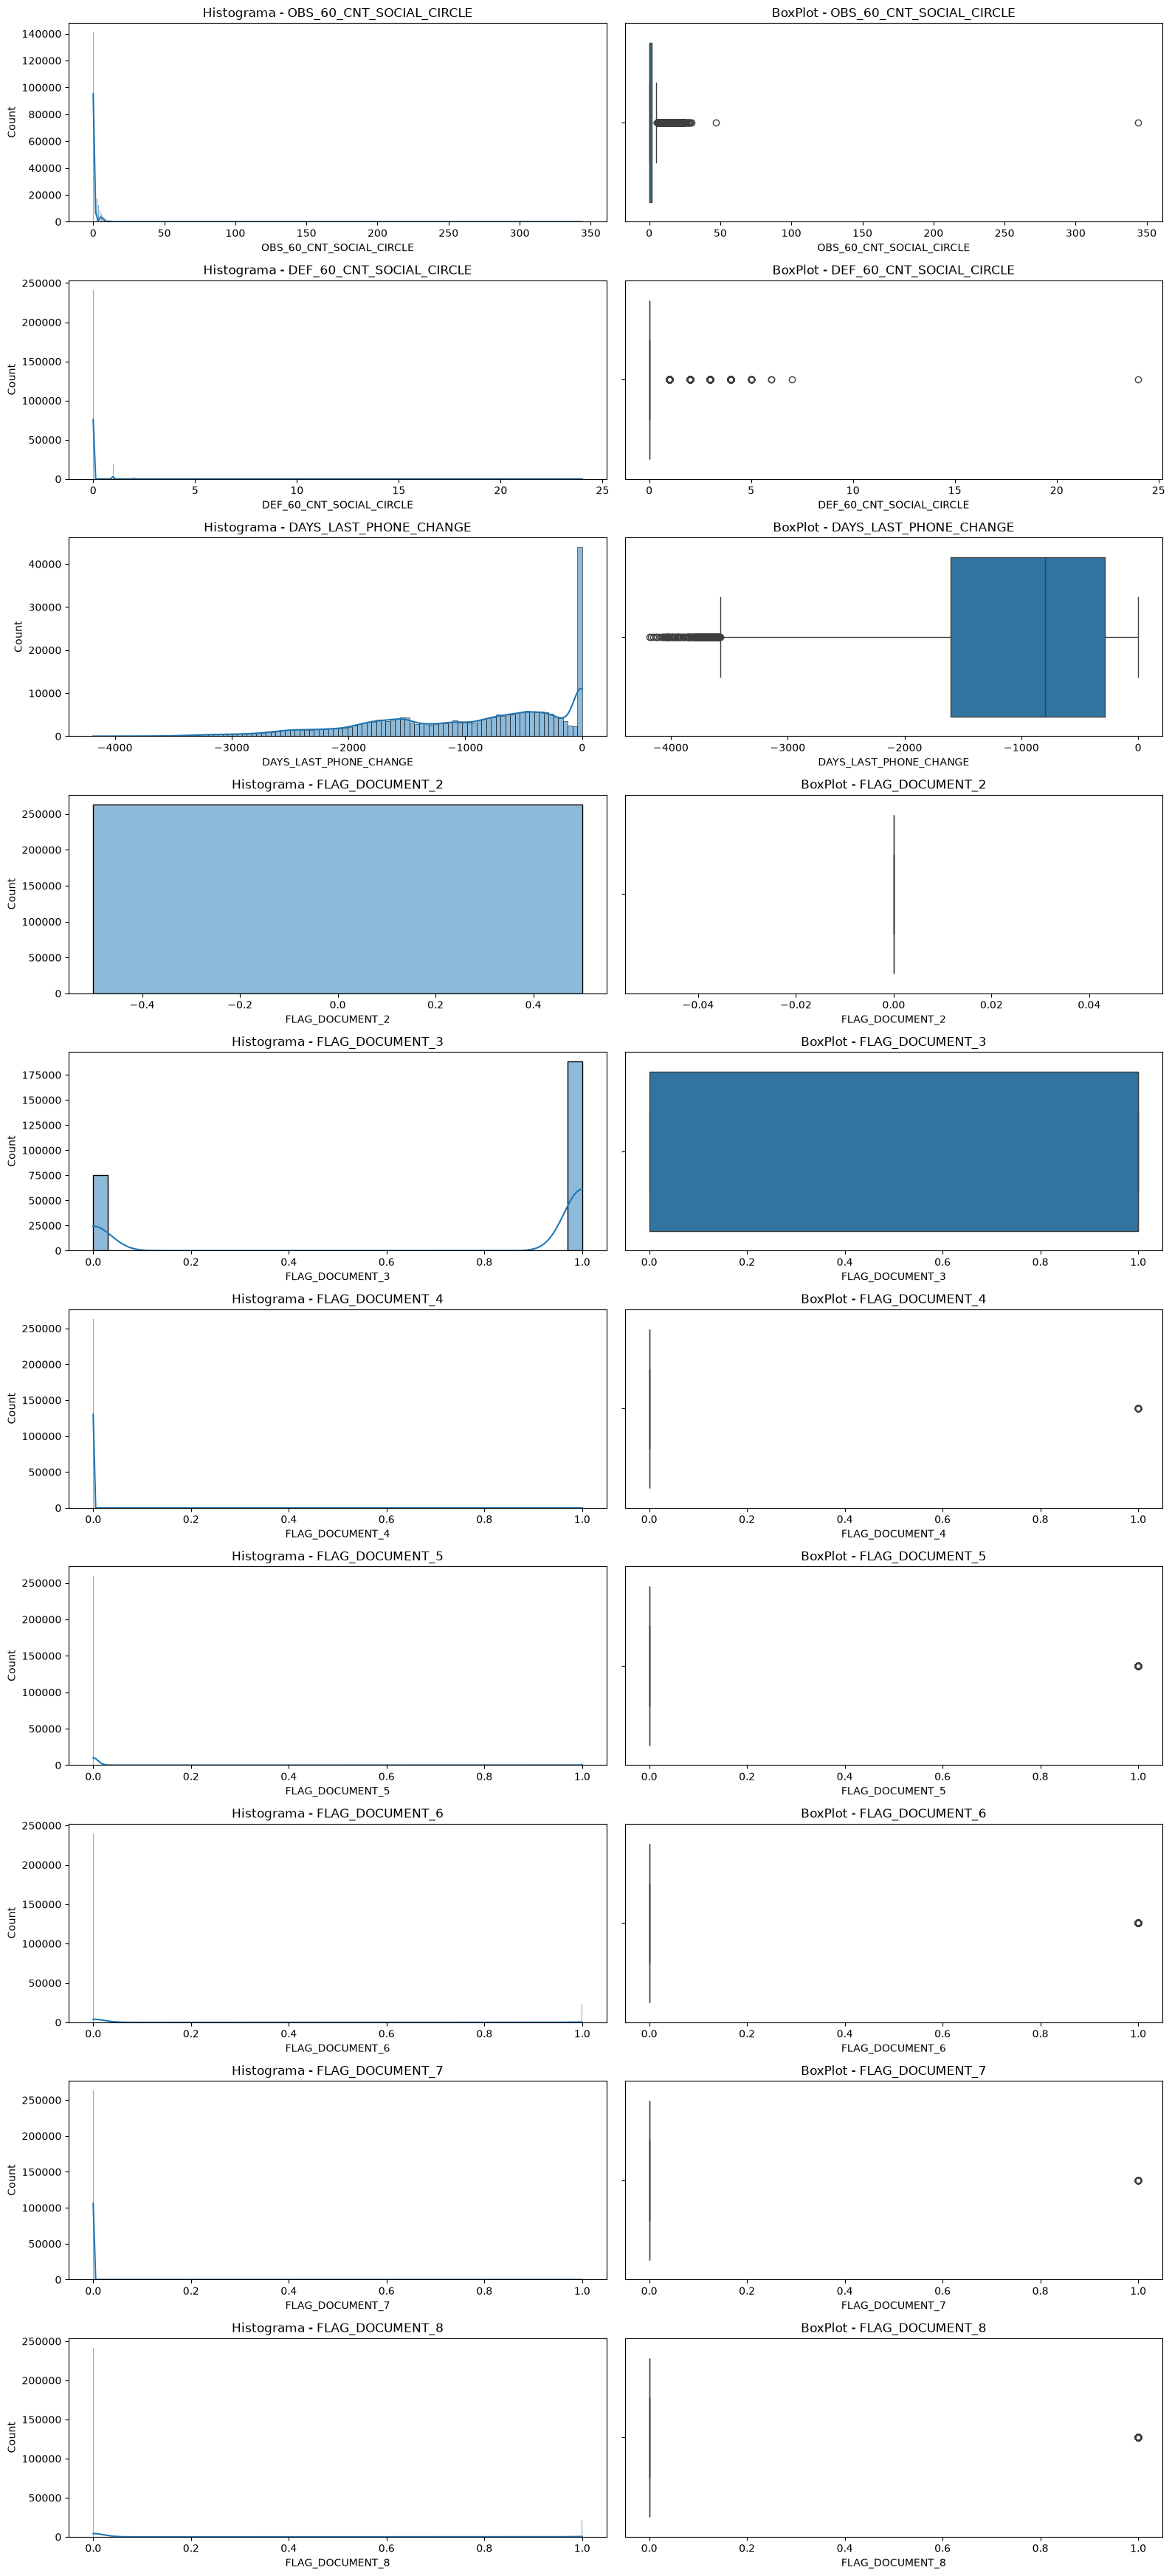

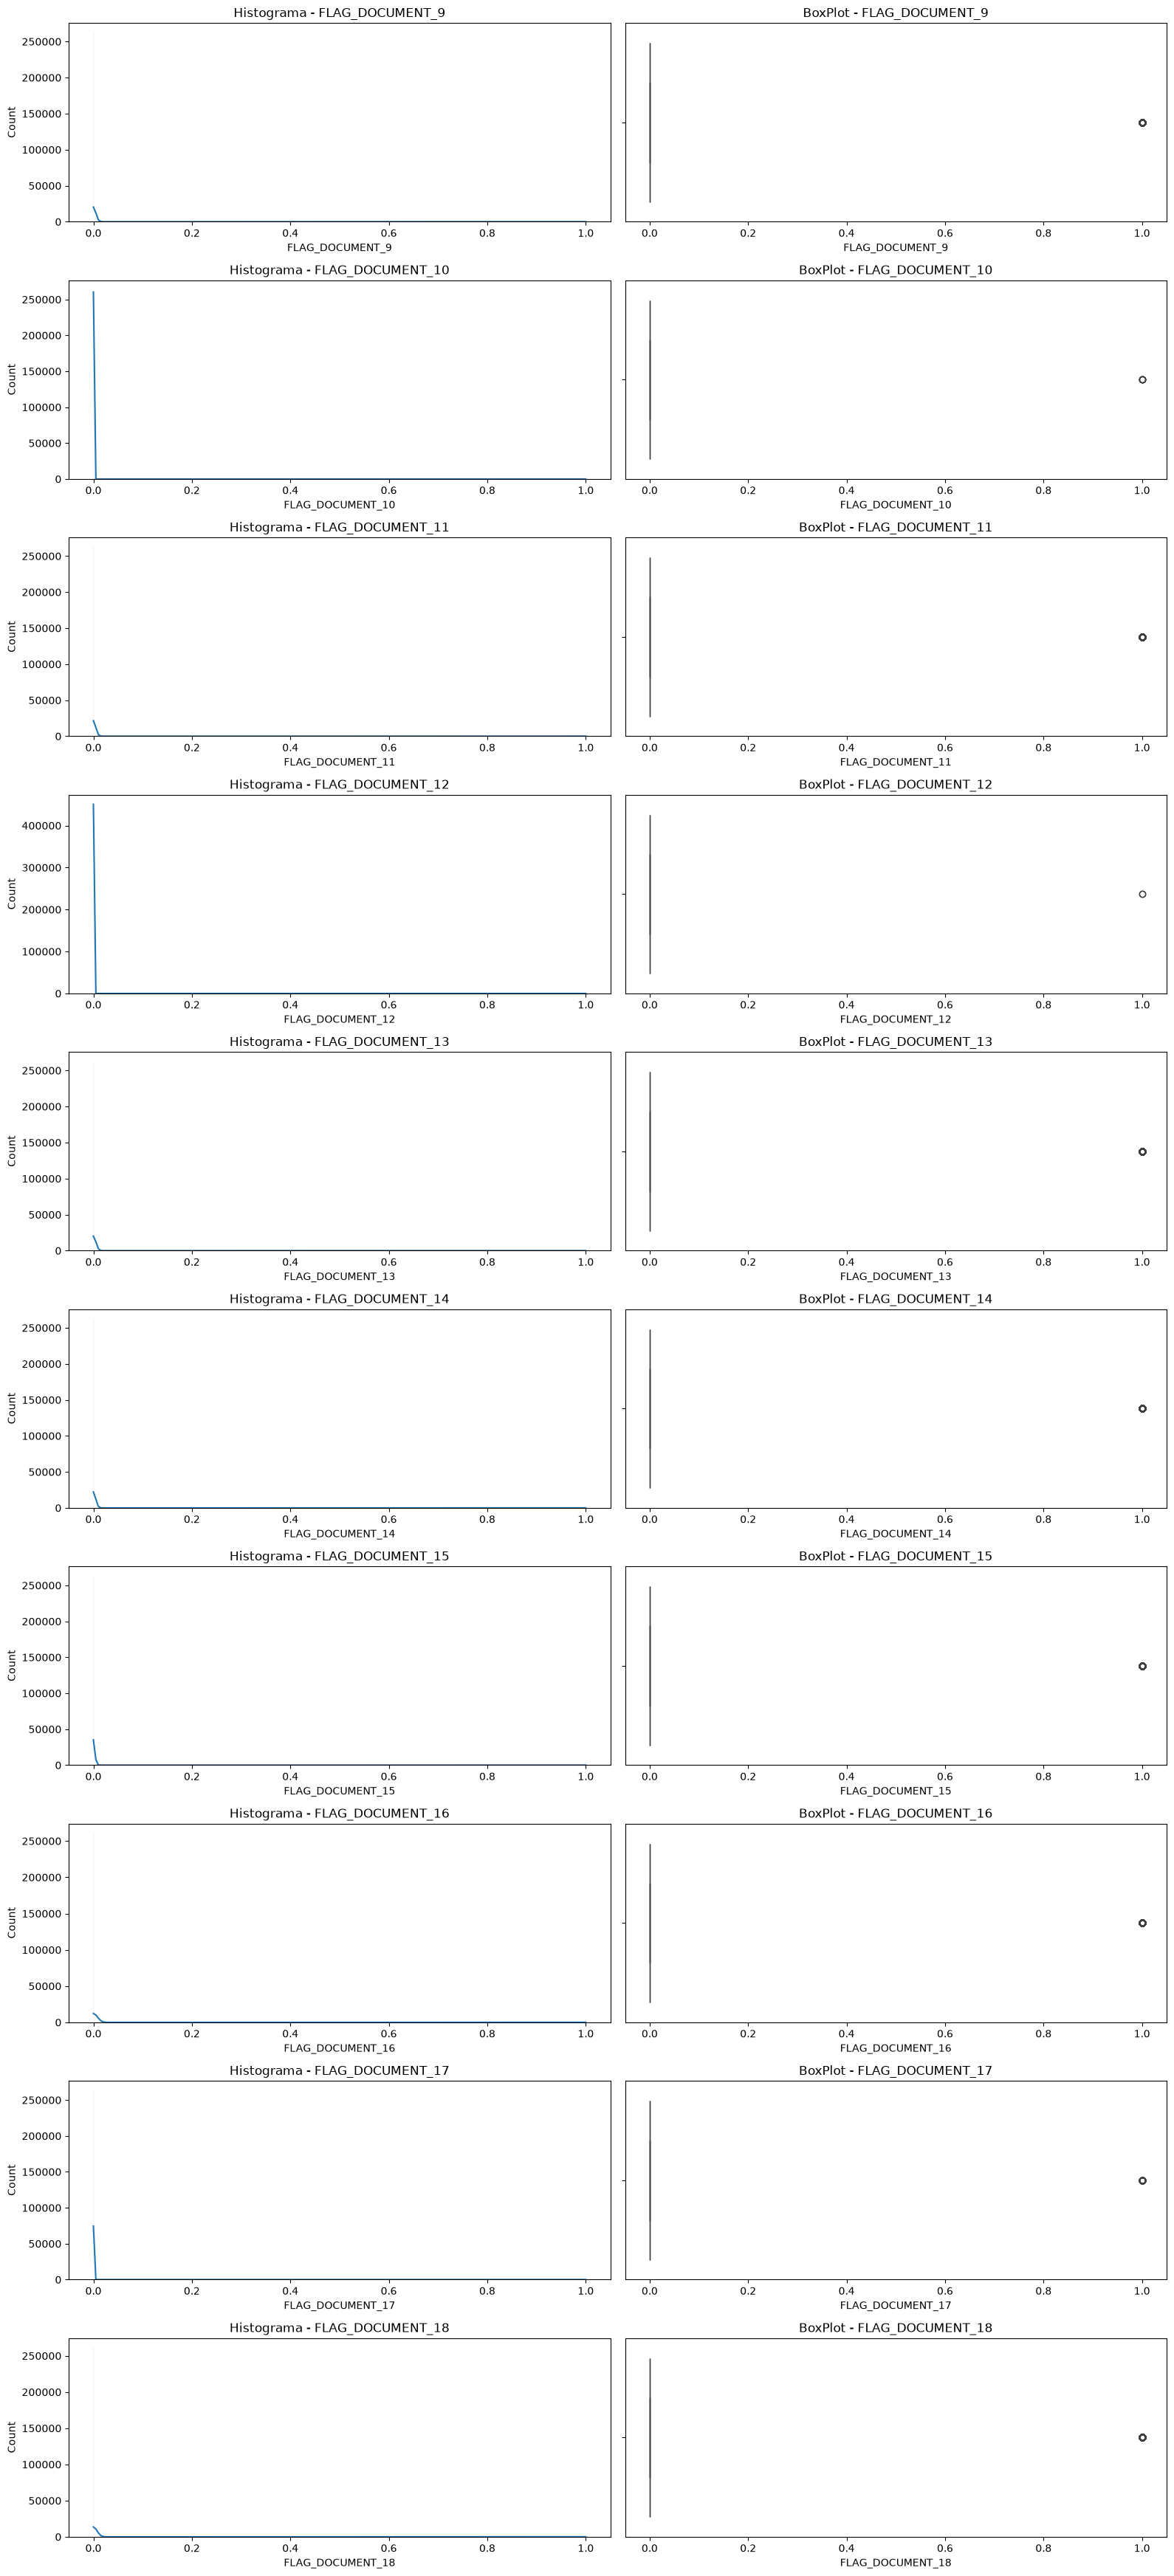

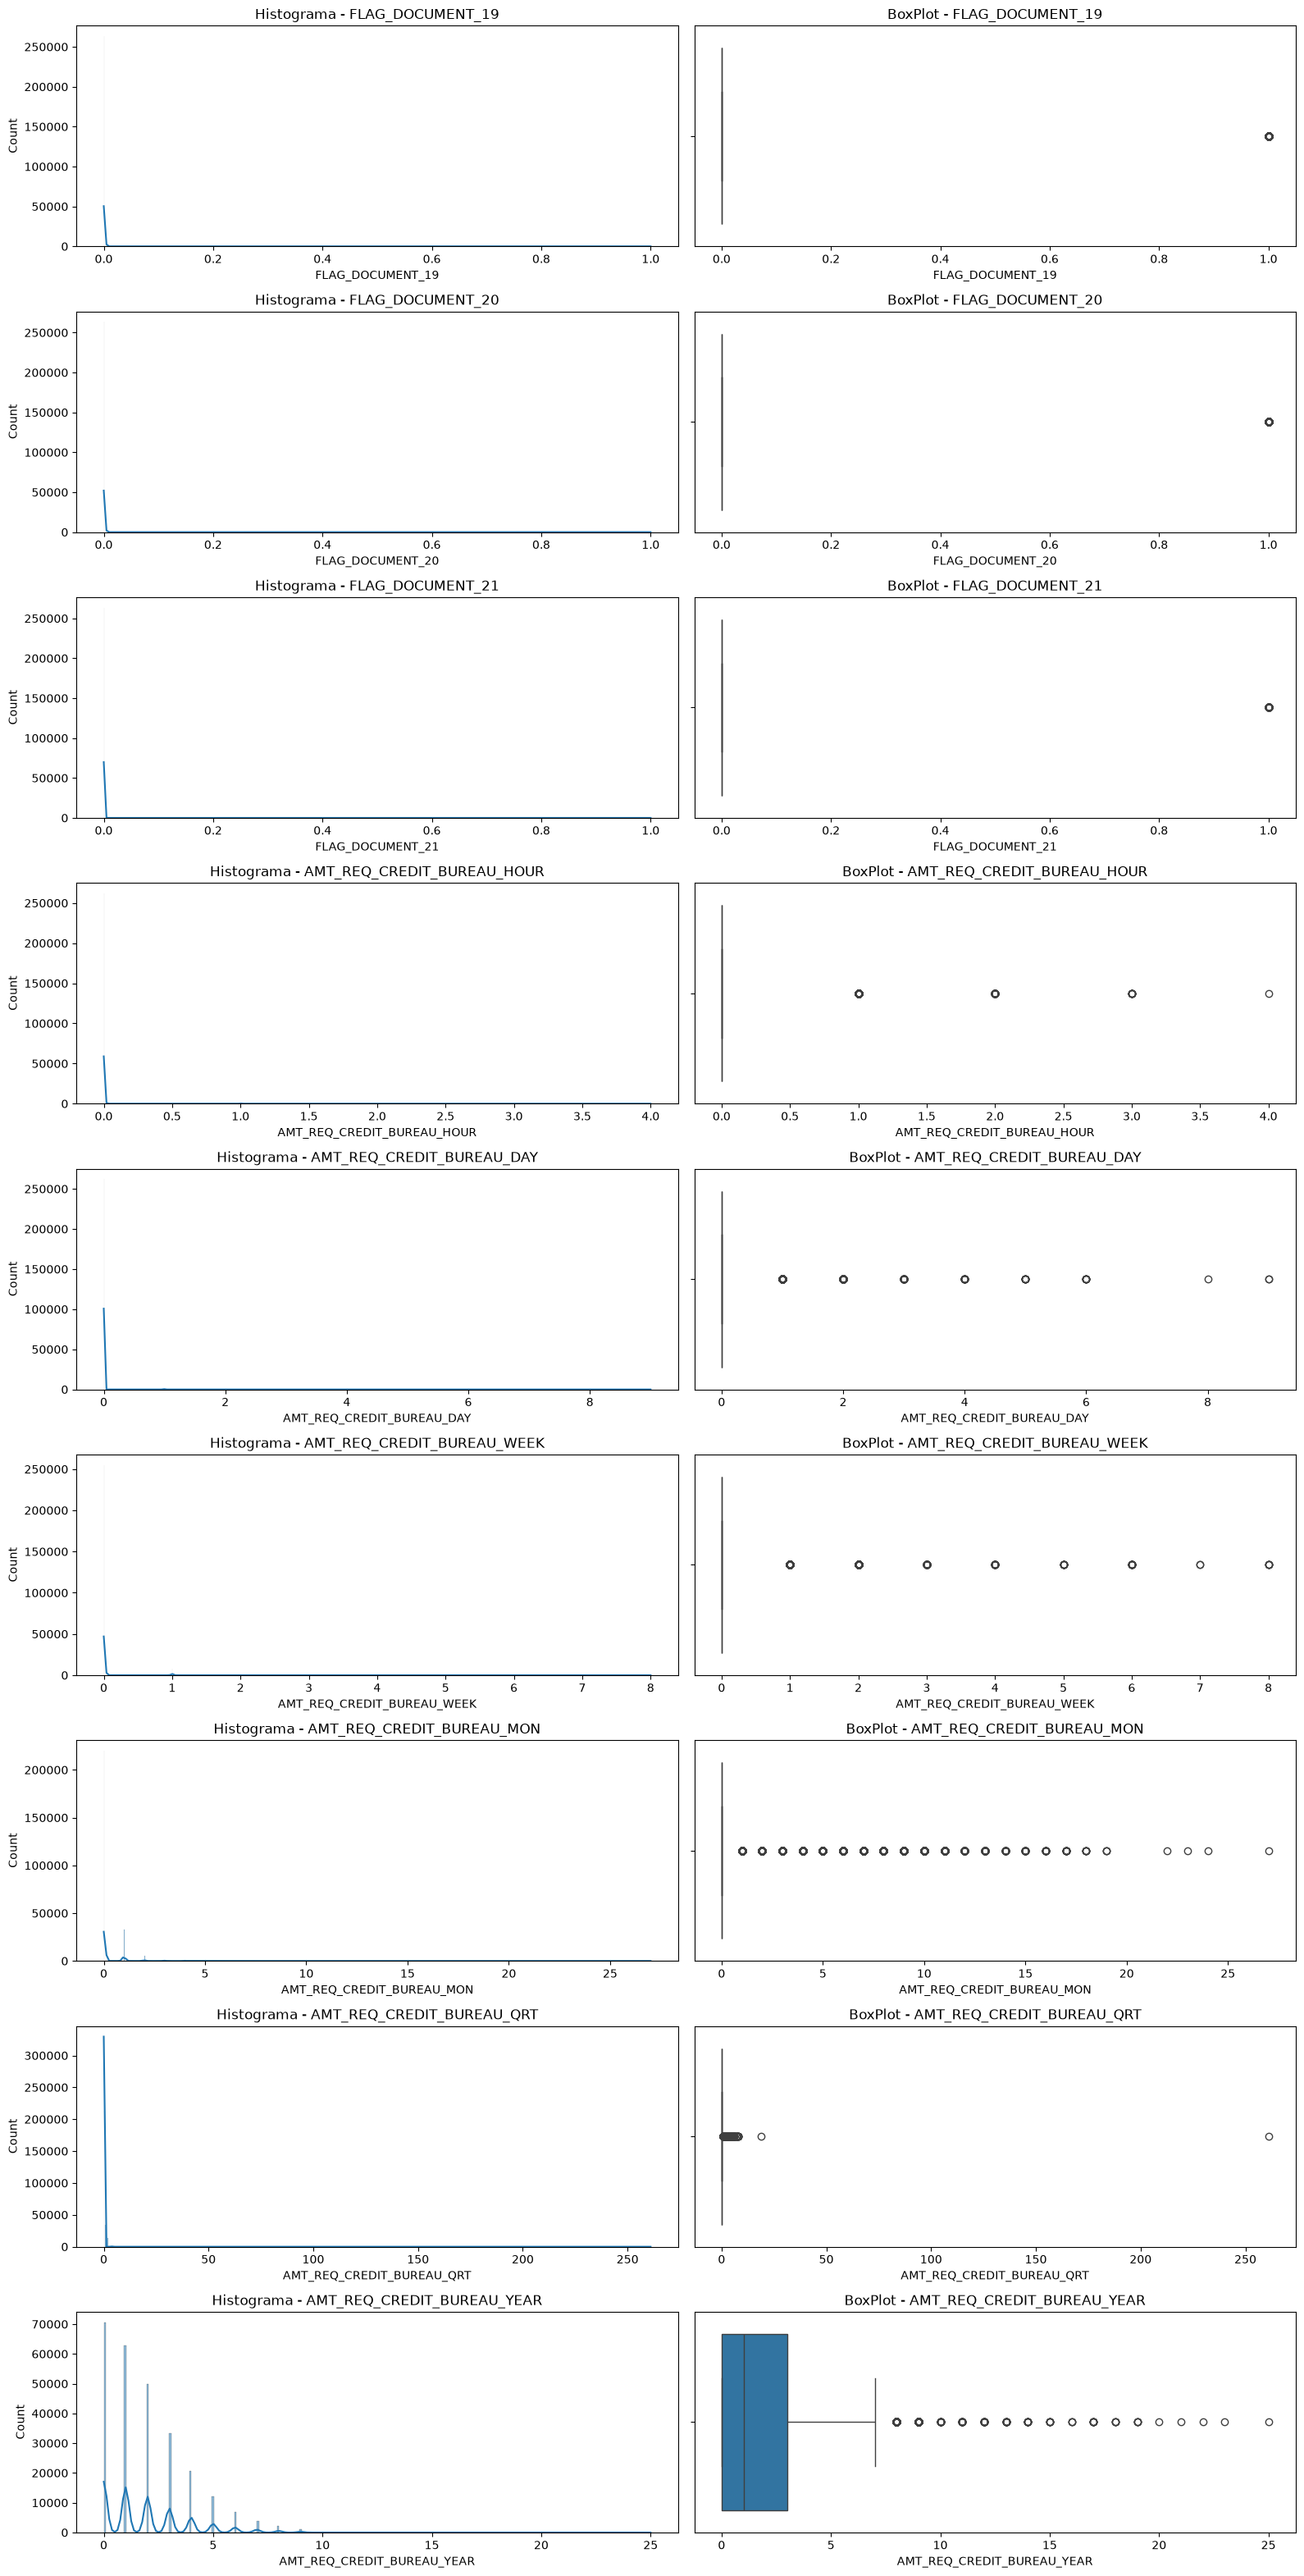

,count,mean,std,min,25%,50%,75%,max
TARGET,263423.0,0.077469,0.267334,0.000000,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,263423.0,0.422716,0.725929,0.000000,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,263423.0,171173.457982,249242.786204,26100.000000,112500.000000,157500.000000,202500.000000,1.170000e+08
AMT_CREDIT,263423.0,606854.688626,404431.082370,45000.000000,273024.000000,521280.000000,814041.000000,4.050000e+06
AMT_ANNUITY,263423.0,27214.157860,14379.858835,1615.500000,16681.500000,25033.500000,34780.500000,2.580255e+05
AMT_GOODS_PRICE,263423.0,545163.714374,371047.173658,40500.000000,238500.000000,450000.000000,688500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,263423.0,0.020812,0.013725,0.000290,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,263423.0,-16118.486336,4307.146141,-25201.000000,-19714.000000,-15815.000000,-12573.000000,-7.489000e+03
DAYS_EMPLOYED,263423.0,63525.504318,141106.557686,-17912.000000,-2847.000000,-1265.000000,-303.000000,3.652430e+05
DAYS_REGISTRATION,263423.0,-4988.379287,3522.296025,-24672.000000,-7477.000000,-4516.000000,-2006.000000,0.000000e+00


In [10]:
# verificando distribuiçao 
plot_cat_num_features(df_train)

In [11]:
# dropando colunas pouco relevantes por redundancia 
df_train = df_train.drop(['FLAG_MOBIL', 'FLAG_DOCUMENT_2'], axis=1)

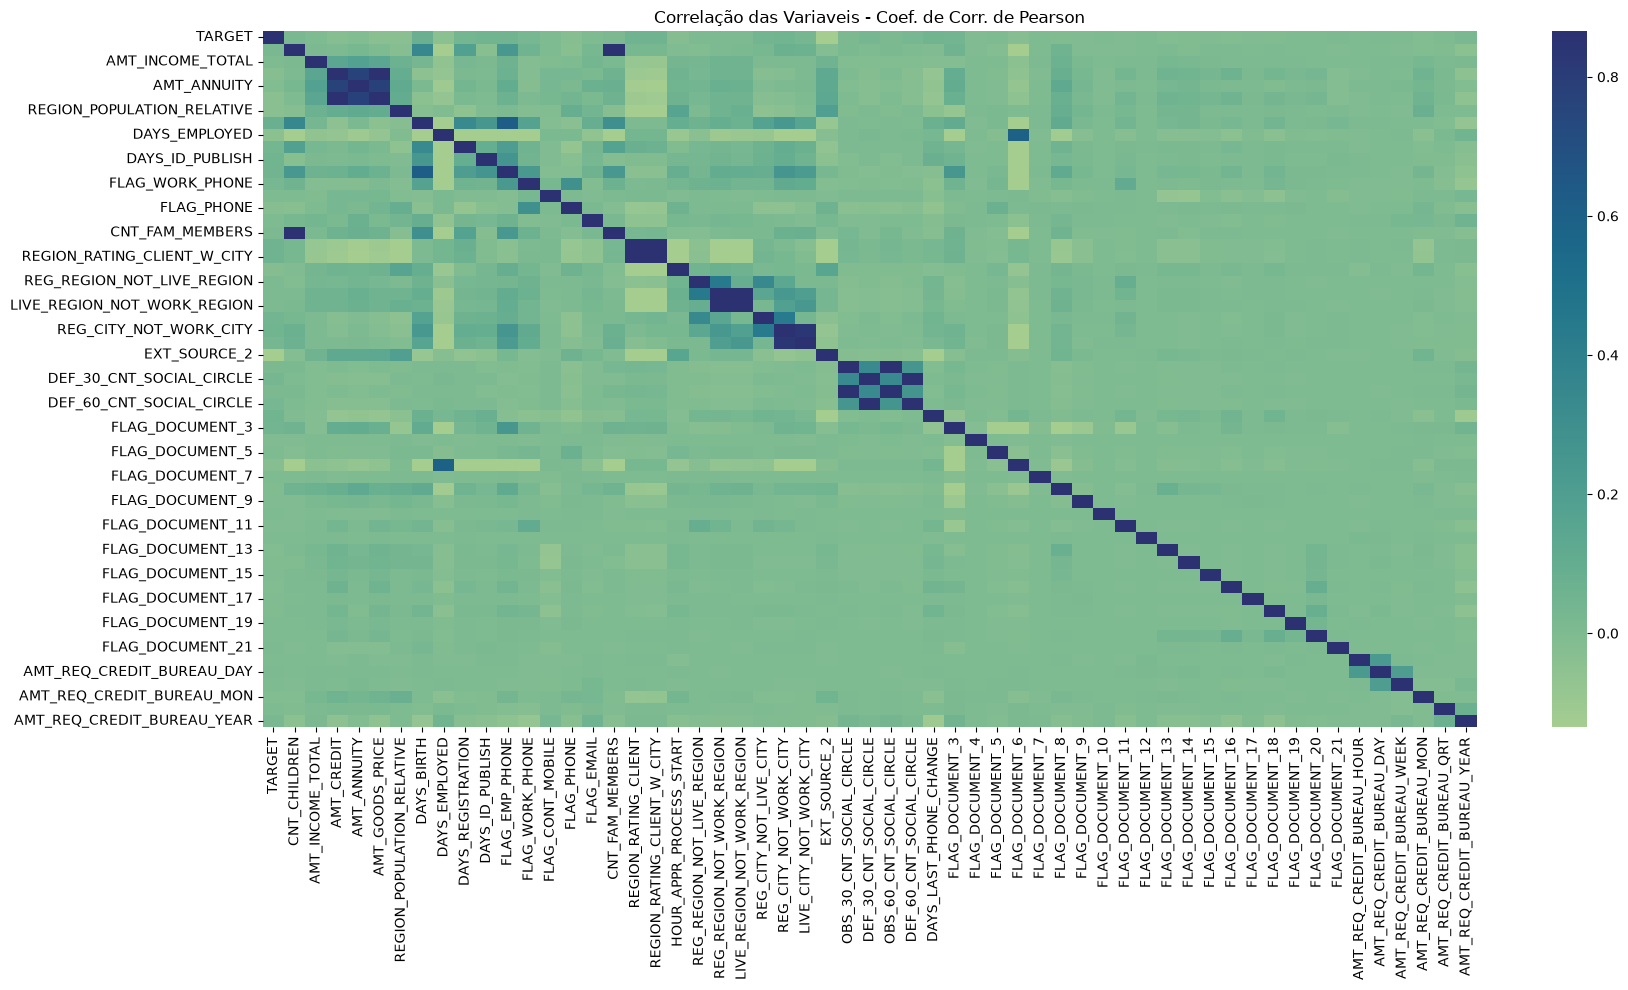

In [12]:
num_cols = df_train.select_dtypes(include='number')
plt.figure(figsize=(18,10))
plt.title('Correlação das Variaveis - Coef. de Corr. de Pearson')
sns.heatmap(num_cols.corr(), cmap='crest', robust=True)
plt.tight_layout()

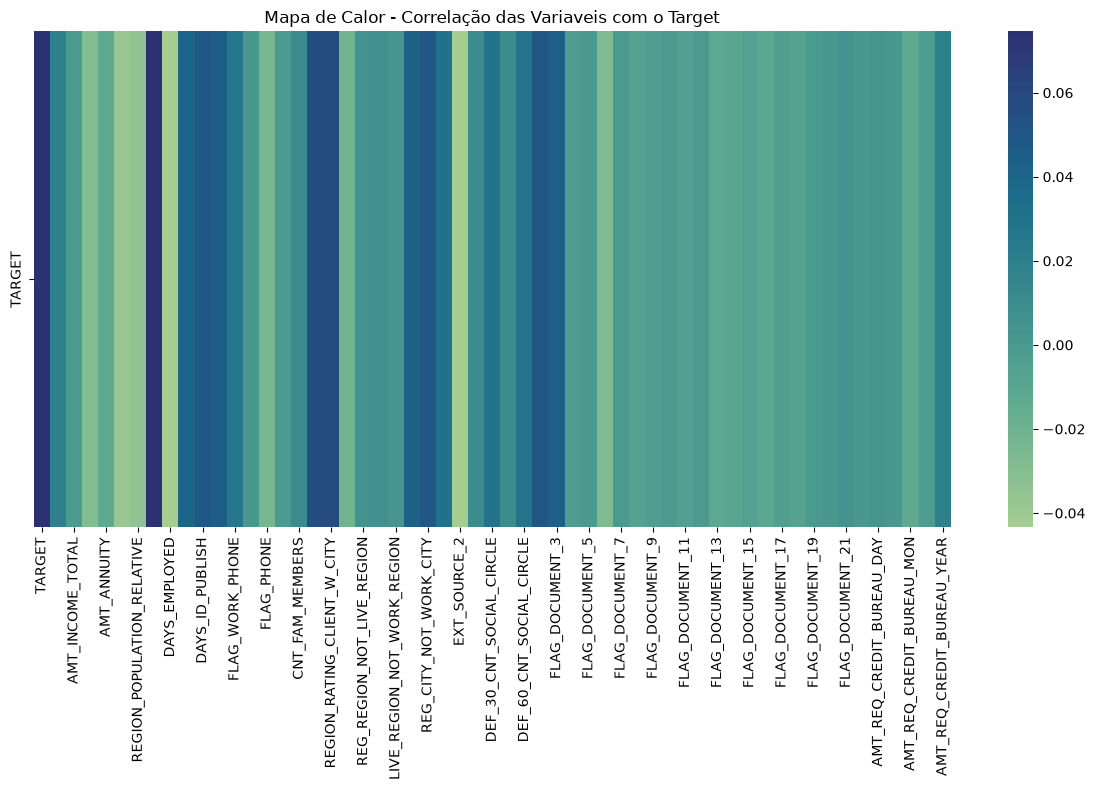

In [13]:
# verificando correlação das variaveis com o target
corr_target = num_cols.corr('pearson')['TARGET']
plot_heatmap(corr_target.to_frame().T, 'Mapa de Calor - Correlação das Variaveis com o Target')

In [14]:
corr_target.sort_values(ascending=False)


TARGET                         1.000000
DAYS_BIRTH                     0.076934
REGION_RATING_CLIENT_W_CITY    0.057493
REGION_RATING_CLIENT           0.055507
DAYS_LAST_PHONE_CHANGE         0.051174
REG_CITY_NOT_WORK_CITY         0.049317
DAYS_ID_PUBLISH                0.049077
FLAG_EMP_PHONE                 0.045160
FLAG_DOCUMENT_3                0.043718
REG_CITY_NOT_LIVE_CITY         0.043156
DAYS_REGISTRATION              0.040395
LIVE_CITY_NOT_WORK_CITY        0.031364
DEF_30_CNT_SOCIAL_CIRCLE       0.029711
DEF_60_CNT_SOCIAL_CIRCLE       0.028536
FLAG_WORK_PHONE                0.026107
AMT_REQ_CREDIT_BUREAU_YEAR     0.019643
CNT_CHILDREN                   0.019359
CNT_FAM_MEMBERS                0.011349
OBS_30_CNT_SOCIAL_CIRCLE       0.009917
OBS_60_CNT_SOCIAL_CIRCLE       0.009865
REG_REGION_NOT_WORK_REGION     0.006615
REG_REGION_NOT_LIVE_REGION     0.005383
FLAG_DOCUMENT_21               0.004457
AMT_REQ_CREDIT_BUREAU_DAY      0.002900
LIVE_REGION_NOT_WORK_REGION    0.002399


In [15]:
df_train

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,454500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456247,0,Cash loans,F,N,Y,0,112500.0,345510.0,17770.5,247500.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0
456249,0,Cash loans,F,N,Y,0,112500.0,225000.0,22050.0,225000.0,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0
456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0


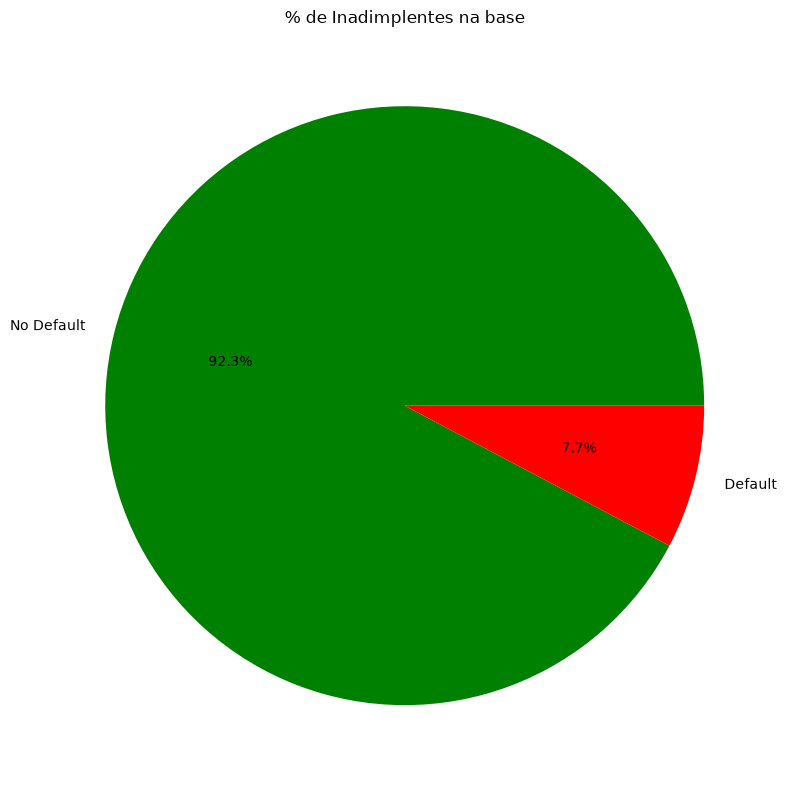

In [16]:
# proporção do valor alvo
target_prop =df_train['TARGET'].value_counts()/df_train.shape[0]
plt.figure(figsize=(12,8))
plt.title('% de Inadimplentes na base')
plt.pie(target_prop, labels=['No Default', 'Default'], autopct='%1.1f%%', colors=['green', 'red'])
plt.tight_layout()
plt.show()

# VIF

In [17]:
# definindo matriz X com o intercepto e calculo do vif
X_constant = sm.add_constant(num_cols)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_constant.columns
vif_data['VIF'] = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]

In [18]:
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
12,FLAG_EMP_PHONE,2328.987978
9,DAYS_EMPLOYED,2309.851786
30,OBS_60_CNT_SOCIAL_CIRCLE,337.662581
28,OBS_30_CNT_SOCIAL_CIRCLE,337.139039
6,AMT_GOODS_PRICE,42.869383
4,AMT_CREDIT,41.936712
18,REGION_RATING_CLIENT,10.744251
19,REGION_RATING_CLIENT_W_CITY,10.591078
22,REG_REGION_NOT_WORK_REGION,9.176109
25,REG_CITY_NOT_WORK_CITY,7.636403


Os dados possuem grande presença de multicolinearidade. Com isso, darei preferencia a modelos nao lineares

In [19]:
df_train['AGE'] = np.round((df_train['DAYS_BIRTH']*-1)/365,0)
df_train = df_train.drop('DAYS_BIRTH', axis=1)

In [20]:
# codificando algumas variaveis categoricas 
df_train['FLAG_OWN_CAR'] = df_train['FLAG_OWN_CAR'].replace({'Y':1, 'N':0})
df_train['FLAG_OWN_CAR'] = pd.to_numeric(df_train['FLAG_OWN_CAR'], errors='coerce')
df_train['FLAG_OWN_REALTY'] = df_train['FLAG_OWN_REALTY'].replace({'Y':1, 'N':0})
df_train['FLAG_OWN_REALTY'] = pd.to_numeric(df_train['FLAG_OWN_REALTY'], errors='coerce')

In [21]:
df_train

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,1,Cash loans,M,0,1,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,26.0
100003,0,Cash loans,F,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,46.0
100004,0,Revolving loans,M,1,1,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.0
100007,0,Cash loans,M,0,1,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,55.0
100008,0,Cash loans,M,0,1,0,99000.0,490495.5,27517.5,454500.0,...,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456247,0,Cash loans,F,0,1,0,112500.0,345510.0,17770.5,247500.0,...,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0,33.0
456249,0,Cash loans,F,0,1,0,112500.0,225000.0,22050.0,225000.0,...,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0,67.0
456253,0,Cash loans,F,0,1,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0,41.0


In [22]:
num_cols.columns

Index(['TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
       'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
       'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
       'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12

In [23]:
# separando colunas categoricas
cat_cols = df_train.select_dtypes(exclude='number').columns
num_cols = num_cols.drop('DAYS_BIRTH', axis=1)

In [24]:
df_train

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,1,Cash loans,M,0,1,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,26.0
100003,0,Cash loans,F,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,46.0
100004,0,Revolving loans,M,1,1,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.0
100007,0,Cash loans,M,0,1,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,55.0
100008,0,Cash loans,M,0,1,0,99000.0,490495.5,27517.5,454500.0,...,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456247,0,Cash loans,F,0,1,0,112500.0,345510.0,17770.5,247500.0,...,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0,33.0
456249,0,Cash loans,F,0,1,0,112500.0,225000.0,22050.0,225000.0,...,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0,67.0
456253,0,Cash loans,F,0,1,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0,41.0




In [25]:
kde_plot(num_cols, 'NAME_CONTRACT_TYPE')

# Modelagem

In [26]:
# divisao treino-test
X = df_train.drop('TARGET', axis=1)
y = df_train['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train)

In [27]:
# dicionarios com modelos
# usando hyperparametros aleatorios
models = {
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
        min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=5, reg_alpha=0.5, gamma=1,
        tree_method='hist', eval_metric='auc',
        random_state=42, n_jobs=-1), 
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=200, min_samples_split=400,
        ccp_alpha=1e-4, random_state=42),
    #'AdaBoost':AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=100),
            
        #n_estimators=300, learning_rate=0.05, random_state=42), 
    
    'Logit': LogisticRegression(C=0.1, penalty='l2', solver='lbfgs',
        max_iter=2000, random_state=42), 

    'GradientBoost': GradientBoostingClassifier(n_estimators=500, learning_rate=0.03, max_depth=3,
        min_samples_leaf=100, subsample=0.8, max_features='sqrt',
        n_iter_no_change=30, validation_fraction=0.1, tol=1e-4,
        random_state=42 )
}


# Catboost

In [28]:
# treino e validaçao com Catboost
cat_boost = CatBoostClassifier(iterations=3000, random_state=42, cat_features=list(cat_cols), verbose=200,  depth=4, 
                            learning_rate=0.03, od_wait=100, l2_leaf_reg=10, auto_class_weights='Balanced')
cat_boost.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

0:	learn: 0.6911051	test: 0.6911345	best: 0.6911345 (0)	total: 423ms	remaining: 21m 9s
200:	learn: 0.6229637	test: 0.6231820	best: 0.6231820 (200)	total: 36.4s	remaining: 8m 27s
400:	learn: 0.6158507	test: 0.6157802	best: 0.6157802 (400)	total: 1m 12s	remaining: 7m 50s
600:	learn: 0.6093642	test: 0.6090737	best: 0.6090737 (600)	total: 1m 54s	remaining: 7m 35s
800:	learn: 0.6046613	test: 0.6041667	best: 0.6041667 (800)	total: 2m 38s	remaining: 7m 13s
1000:	learn: 0.6008979	test: 0.6005492	best: 0.6005492 (1000)	total: 3m 18s	remaining: 6m 36s
1200:	learn: 0.5976272	test: 0.5973958	best: 0.5973958 (1200)	total: 3m 58s	remaining: 5m 57s
1400:	learn: 0.5946436	test: 0.5945483	best: 0.5945483 (1400)	total: 4m 38s	remaining: 5m 18s
1600:	learn: 0.5917620	test: 0.5918198	best: 0.5918198 (1600)	total: 5m 19s	remaining: 4m 39s
1800:	learn: 0.5890953	test: 0.5892764	best: 0.5892764 (1800)	total: 6m 2s	remaining: 4m 1s
2000:	learn: 0.5865931	test: 0.5870234	best: 0.5870234 (2000)	total: 6m 42s	re

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE'], depth=4, iterations=3000, l2_leaf_reg=10, learning_rate=0.03, od_wait=100, random_state=42, verbose=200)

In [42]:
# fazendo previsoes para o modelo de catboost 
cat_pred_train = cat_boost.predict_proba(X_train)[:,1]
cat_pred_test = cat_boost.predict_proba(X_test)[:,1]

In [38]:
# metricas de treino 
metrics(y_train, cat_pred_train, 0.45)


,KS,Recall Score,LogLoss,Roc Auc,F1
0,0.399379,0.774583,0.578456,0.770461,0.245314


In [43]:
# metricas de teste
metrics(y_test, cat_pred_test, 0.45)

,KS,Recall Score,LogLoss,Roc Auc,F1
0,0.315477,0.696227,0.588497,0.717592,0.219833


# Treinamento dos modelos

In [32]:
cat_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE'],
      dtype='str')

In [33]:
# criando pipeline 
column_trans = ColumnTransformer([
    ('num', StandardScaler(), num_cols.drop('TARGET',axis=1).columns),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
pipe = Pipeline(steps=[
    ('preprocessing', column_trans), 
    ('model', LogisticRegression(random_state=42, class_weight='balanced'))
])


In [34]:
# treinamento dos modelos 
# sample_weight
w_train = compute_sample_weight(class_weight='balanced', y=y_train)
for i, model in models.items():
    print(f'Treinando modelo {i}')
    model_ = pipe.set_params(model=model).fit(X_train, y_train, model__sample_weight=w_train)
    train_p = model_.predict_proba(X_train)[:,1]
    valid_p = model_.predict_proba(X_val)[:,1]
    print()
    print(f'Metrica de treino {i}')
    print(metrics(y_train, train_p, 0.45))
    print()
    print(f'metricas de Valid {i}')
    print(metrics(y_val, valid_p, 0.45))

Treinando modelo XGBoost

Metrica de treino XGBoost
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.367819       0.76255  0.594428  0.749978  0.232178

metricas de Valid XGBoost
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.367969      0.757964  0.594761  0.749442  0.230425
Treinando modelo Decision Tree

Metrica de treino Decision Tree
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.267582       0.73097  0.639027  0.682869  0.197757

metricas de Valid Decision Tree
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.264993      0.734005  0.640423  0.681341  0.198959
Treinando modelo Logit

Metrica de treino Logit
         KS  Recall Score  LogLoss   Roc Auc        F1
0  0.299894      0.731243  0.62524  0.705635  0.209734

metricas de Valid Logit
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.298107      0.723931  0.627184  0.701459  0.207071
Treinando modelo GradientBoost

Metrica de treino GradientBoost
         KS  Reca

# Feature Eng.

In [88]:
# criando novo dataframe de treino
X_train_eng = X_train.copy()


In [93]:
# features baseadas em renda 
X_train_eng['PCT_INCOME_CREDIT'] = X_train_eng['AMT_INCOME_TOTAL']/ X_train_eng['AMT_CREDIT']
X_train_eng['PCT_INCOME_ANNUITY'] = X_train_eng['AMT_ANNUITY']/X_train_eng['AMT_INCOME_TOTAL']
X_train_eng['PRICE_PER_CREDIT'] =  X_train_eng['AMT_GOODS_PRICE']/X_train_eng['AMT_CREDIT']
X_train_eng['CNT_FAM_MEMBERS_PER_INCOME'] = X_train_eng['AMT_INCOME_TOTAL']/X_train_eng['CNT_FAM_MEMBERS']

In [94]:
# features baseadas em dias (tempo de relacionamento e trabalho)
X_train_eng['DAYS_EMPLOYED'] = np.where(X_train_eng['DAYS_EMPLOYED']==365243, 0,X_train_eng['DAYS_EMPLOYED'] )
X_train_eng['DAYS_EMPLOYED'] = np.where(X_train_eng['DAYS_EMPLOYED']<0, X_train_eng['DAYS_EMPLOYED']*-1, X_train_eng['DAYS_EMPLOYED'])
X_train_eng['Y_EMPLOYED'] = X_train_eng['DAYS_EMPLOYED']/365

In [99]:
def feature_eng(data:pd.DataFrame):
    X_train_eng = data.copy()
    X_train_eng['PCT_INCOME_CREDIT'] = X_train_eng['AMT_INCOME_TOTAL']/ X_train_eng['AMT_CREDIT']
    X_train_eng['PCT_INCOME_ANNUITY'] = X_train_eng['AMT_ANNUITY']/X_train_eng['AMT_INCOME_TOTAL']
    X_train_eng['PRICE_PER_CREDIT'] =  X_train_eng['AMT_GOODS_PRICE']/X_train_eng['AMT_CREDIT']
    X_train_eng['CNT_FAM_MEMBERS_PER_INCOME'] = X_train_eng['AMT_INCOME_TOTAL']/X_train_eng['CNT_FAM_MEMBERS']
    X_train_eng['DAYS_EMPLOYED'] = np.where(X_train_eng['DAYS_EMPLOYED']==365243, 0,X_train_eng['DAYS_EMPLOYED'] )
    X_train_eng['DAYS_EMPLOYED'] = np.where(X_train_eng['DAYS_EMPLOYED']<0, X_train_eng['DAYS_EMPLOYED']*-1, X_train_eng['DAYS_EMPLOYED'])
    X_train_eng['Y_EMPLOYED'] = X_train_eng['DAYS_EMPLOYED']/365
    
    return X_train_eng

In [101]:
X_val_eng = feature_eng(X_val)
X_val_eng 

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE,PCT_INCOME_CREDIT,PCT_INCOME_ANNUITY,PRICE_PER_CREDIT,CNT_FAM_MEMBERS_PER_INCOME,Y_EMPLOYED
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
275262,Cash loans,F,0,0,1,270000.0,700830.0,20619.0,585000.0,Unaccompanied,...,0.0,1.0,2.0,5.0,36.0,0.385257,0.076367,0.834725,90000.0,8.682192
107094,Cash loans,F,1,1,0,157500.0,825588.0,82620.0,765000.0,Family,...,0.0,1.0,2.0,1.0,27.0,0.190773,0.524571,0.926612,78750.0,8.805479
115564,Cash loans,F,0,1,0,157500.0,651816.0,23409.0,495000.0,Unaccompanied,...,0.0,0.0,0.0,4.0,51.0,0.241633,0.148629,0.759417,78750.0,7.350685
120487,Cash loans,F,0,1,0,135000.0,407965.5,42970.5,369000.0,Unaccompanied,...,0.0,0.0,0.0,9.0,62.0,0.330910,0.318300,0.904488,135000.0,0.000000
386646,Cash loans,F,0,1,0,135000.0,781920.0,28215.0,675000.0,Family,...,0.0,0.0,0.0,2.0,60.0,0.172652,0.209000,0.863260,67500.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382349,Cash loans,F,1,1,0,94500.0,225000.0,26703.0,225000.0,Unaccompanied,...,0.0,0.0,1.0,5.0,45.0,0.420000,0.282571,1.000000,47250.0,7.167123
348674,Cash loans,F,0,0,1,153000.0,168102.0,16753.5,148500.0,Unaccompanied,...,0.0,0.0,0.0,0.0,34.0,0.910162,0.109500,0.883392,51000.0,8.230137
313991,Cash loans,F,0,1,0,198000.0,246357.0,25371.0,234000.0,Unaccompanied,...,0.0,0.0,0.0,2.0,57.0,0.803712,0.128136,0.949841,99000.0,29.427397


In [102]:
# nova rodada de treino 
for i, model in models.items():
    print(f'Treinando modelo {i}')
    model_train = pipe.set_params(model=model).fit(X_train_eng, y_train)
    val_pred = model_train.predict_proba(X_val_eng)[:,1]
    train_pred = model_train.predict_proba(X_train_eng)[:,1]
    print('Métrica de treino:')
    print(metrics(y_train, train_pred, 0.45))
    print('Metrica de validaçao:')
    print(metrics(y_val, val_pred, 0.45))
    

Treinando modelo XGBoost
Métrica de treino:
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.360192      0.011924  0.243376  0.744876  0.023362
Metrica de validaçao:
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.359909      0.011979  0.243261  0.744483  0.023467
Treinando modelo Decision Tree
Métrica de treino:
         KS  Recall Score   LogLoss   Roc Auc   F1
0  0.233854           0.0  0.260548  0.651842  0.0
Metrica de validaçao:
         KS  Recall Score   LogLoss   Roc Auc   F1
0  0.229766           0.0  0.260956  0.648253  0.0
Treinando modelo Logit
Métrica de treino:
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.303191      0.001742  0.251876  0.706916  0.003472
Metrica de validaçao:
         KS  Recall Score  LogLoss   Roc Auc        F1
0  0.301931      0.002178  0.25273  0.702758  0.004338
Treinando modelo GradientBoost
Métrica de treino:
         KS  Recall Score   LogLoss   Roc Auc        F1
0  0.325154      0.005336  0.249254  0.720

In [103]:
X_train.columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
       'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'OBS_30_CNT_SOCIAL_CIRCLE',
       'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
       'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_P

In [104]:
X_train

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
432738,Cash loans,F,0,1,0,76500.0,225000.0,13896.0,225000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0,66.0
368399,Cash loans,M,1,1,0,180000.0,765000.0,22495.5,765000.0,Unaccompanied,...,0,0,0,0.0,0.0,1.0,3.0,0.0,4.0,37.0
131444,Cash loans,F,0,1,0,157500.0,701730.0,66757.5,675000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,61.0
316598,Cash loans,F,0,1,0,112500.0,251280.0,11196.0,180000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,59.0
444272,Cash loans,F,1,1,0,90000.0,188685.0,14728.5,157500.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,42.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360582,Cash loans,F,1,1,0,157500.0,130320.0,13815.0,112500.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0,37.0
444946,Cash loans,F,0,1,0,202500.0,675000.0,32602.5,675000.0,Family,...,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0,35.0
289519,Revolving loans,M,0,0,0,180000.0,270000.0,13500.0,270000.0,Family,...,0,0,0,0.0,0.0,1.0,1.0,1.0,2.0,62.0
